## Modelo de Regresión con Random Forest

Entrenamiento de un modelo Random Forest para predecir las ganancias totales diarias usando los datos de entrenamiento, validación y prueba.

#### Librerías necesarias

Las librerías necesarias son las siguientes:

- Pandas: para la manipulación de datos.
- NumPy: para operaciones numéricas.
- Matplotlib: para visualización de datos.
- Scikit-learn: para el modelado de machine learning, incluyendo Random Forest y métricas de evaluación.

In [66]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

#### Carga del dataset.

Se cargan los datasets de entrenamiento, validación y prueba desde los archivos CSV generados en el paso de preprocesamiento.

In [67]:
df_train = pd.read_csv('../../output/regresion/data_train_regresion.csv', encoding='ISO-8859-1')
df_validation = pd.read_csv('../../output/regresion/data_validation_regresion.csv', encoding='ISO-8859-1')
df_test = pd.read_csv('../../output/regresion/data_test_regresion.csv', encoding='ISO-8859-1')

print(f"Train: {df_train.shape}")
print(f"Validation: {df_validation.shape}")
print(f"Test: {df_test.shape}")
print(f"\nColumnas: {df_train.columns.tolist()}")

Train: (220, 9)
Validation: (55, 9)
Test: (17, 9)

Columnas: ['GananciasTotales', 'DiaMes', 'Lag_1_Ventas', 'DiaSemana_Domingo', 'DiaSemana_Jueves', 'DiaSemana_Lunes', 'DiaSemana_Martes', 'DiaSemana_Miercoles', 'DiaSemana_Viernes']


#### Preparación de features y target.

Se separan las características (features) de la variable objetivo (target) en los datasets de entrenamiento, validación y prueba.

In [68]:
X_train = df_train.drop('GananciasTotales', axis=1)
y_train = df_train['GananciasTotales'].values

X_validation = df_validation.drop('GananciasTotales', axis=1)
y_validation = df_validation['GananciasTotales'].values

X_test = df_test.drop('GananciasTotales', axis=1)
y_test = df_test['GananciasTotales'].values

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nPrimeras 5 filas de X_train:")
print(X_train.head())

X_train shape: (220, 8)
y_train shape: (220,)

Primeras 5 filas de X_train:
   DiaMes  Lag_1_Ventas  DiaSemana_Domingo  DiaSemana_Jueves  DiaSemana_Lunes  \
0       2      1.525539                0.0               1.0              0.0   
1       3      0.942194                0.0               0.0              0.0   
2       5      0.843943                1.0               0.0              0.0   
3       6      0.593427                0.0               0.0              1.0   
4       7      2.180166                0.0               0.0              0.0   

   DiaSemana_Martes  DiaSemana_Miercoles  DiaSemana_Viernes  
0               0.0                  0.0                0.0  
1               0.0                  0.0                1.0  
2               0.0                  0.0                0.0  
3               0.0                  0.0                0.0  
4               1.0                  0.0                0.0  


#### Entrenamiento del modelo Random Forest.

A continuación se entrena el modelo Random Forest utilizando el dataset de entrenamiento. Se ajustan los hiperparámetros del modelo para mejorar su rendimiento.

Los hiperparámetros ajustados incluyen:

- n_estimators: número de árboles en el bosque.

- max_depth: profundidad máxima de los árboles.

- min_samples_split: número mínimo de muestras necesarias para dividir un nodo.

- min_samples_leaf: número mínimo de muestras necesarias para estar en un nodo hoja.

- max_features: número de características a considerar para encontrar la mejor división.

- n_jobs: número de trabajos a ejecutar en paralelo para el ajuste de hiperparámetros.

En este caso, se han utilizado los siguientes valores para los hiperparámetros:

- n_estimators: 100

- max_depth: None

- min_samples_split: 2

- min_samples_leaf: 1

- max_features: 'sqrt'

- n_jobs: -1

In [69]:
model = RandomForestRegressor(
  n_estimators=100,
  max_depth=10,
  min_samples_split=5,
  max_features='log2',
  random_state=42,
  n_jobs=-1
)

model.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente")

Modelo Random Forest entrenado correctamente


#### Evaluación del modelo.

Se evalúa el rendimiento del modelo en los tres conjuntos de datos (entrenamiento, validación y prueba) utilizando las siguientes métricas:

Estas métricas permiten detectar posible overfitting (diferencia significativa entre train y test) y evaluar la generalización del modelo. Un buen modelo debe tener métricas similares en los tres conjuntos de datos.

- MAE (Mean Absolute Error): error medio absoluto en euros, interpretable directamente.

- R² (Coeficiente de Determinación): proporción de varianza explicada por el modelo (0-1).- RMSE (Root Mean Squared Error): error cuadrático medio, penalizando más los errores grandes.

In [70]:
y_train_pred = model.predict(X_train)
y_validation_pred = model.predict(X_validation)
y_test_pred = model.predict(X_test)

def evaluar_modelo(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  return mae, r2, rmse

mae_train, r2_train, rmse_train = evaluar_modelo(y_train, y_train_pred)
print(f"\nENTRENAMIENTO:")
print(f"  MAE:  {mae_train:.2f}")
print(f"  R²:    {r2_train:.2f}")
print(f"  RMSE:  {rmse_train:.2f}")
mae_validation, r2_validation, rmse_validation = evaluar_modelo(y_validation, y_validation_pred)
print(f"\nVALIDACIÓN:")
print(f"  MAE:  {mae_validation:.2f}")
print(f"  R²:    {r2_validation:.2f}")
print(f"  RMSE:  {rmse_validation:.2f}")
mae_test, r2_test, rmse_test = evaluar_modelo(y_test, y_test_pred)
print(f"\nTEST:")
print(f"  MAE:  {mae_test:.2f}")
print(f"  R²:    {r2_test:.2f}")
print(f"  RMSE:  {rmse_test:.2f}")


ENTRENAMIENTO:
  MAE:  0.27
  R²:    0.81
  RMSE:  0.35

VALIDACIÓN:
  MAE:  0.82
  R²:    -0.41
  RMSE:  1.04

TEST:
  MAE:  1.04
  R²:    -1.18
  RMSE:  1.19


#### Importancia de features.

Se analizan las características más importantes del modelo Random Forest. Random Forest calcula la importancia de cada característica basándose en cuánto reduce la impureza en los árboles durante el entrenamiento.

La visualización de barras facilita la identificación rápida de los predictores más influyentes.

Esta información revela:

- Características que podrían ser descartadas si su importancia es muy baja.

- Qué variables tienen mayor influencia en la predicción de ganancias diarias.- Potenciales relaciones entre variables y el objetivo (GananciasTotales).
- Las características más relevantes para el modelo de negocio.


Importancia de features:
            feature  importance
       Lag_1_Ventas    0.414167
  DiaSemana_Domingo    0.269887
             DiaMes    0.190378
   DiaSemana_Jueves    0.043953
   DiaSemana_Martes    0.023456
    DiaSemana_Lunes    0.022719
  DiaSemana_Viernes    0.018589
DiaSemana_Miercoles    0.016851


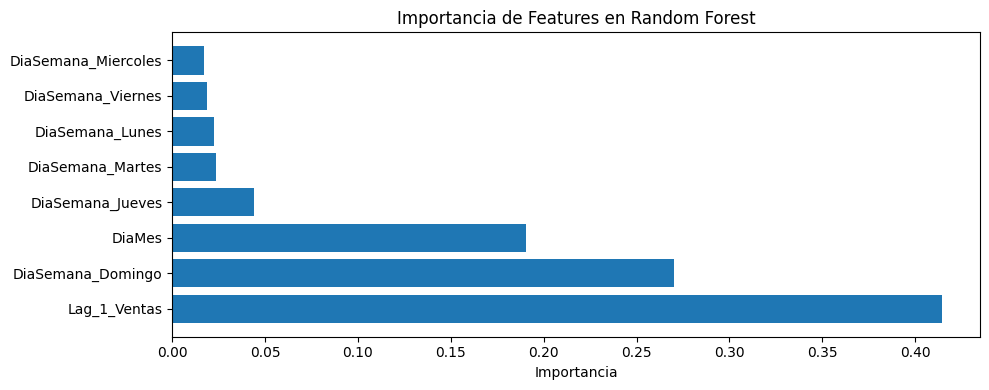

In [71]:
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
  'feature': X_train.columns,
  'importance': importances
}).sort_values('importance', ascending=False)

print("\nImportancia de features:")
print(feature_importance_df.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importancia')
plt.title('Importancia de Features en Random Forest')
plt.tight_layout()
plt.show()

#### Visualización de predicciones vs realidad.

Se visualizan las predicciones del modelo comparadas con los valores reales en los tres conjuntos de datos. Esta visualización permite observar:

Los títulos muestran el MAE (error medio absoluto) para cada conjunto, permitiendo una evaluación rápida del desempeño en cada fase.

- **Capacidad predictiva**: si el modelo captura las tendencias y patrones de las ganancias diarias.

- **Sesgo del modelo**: si tiende a subestimar o sobrestimar los valores reales.- **Patrones temporales**: si el modelo mantiene consistencia a lo largo de los diferentes períodos.
- **Estabilidad**: comparar el rendimiento entre entrenamiento, validación y test para detectar problemas de generalización.

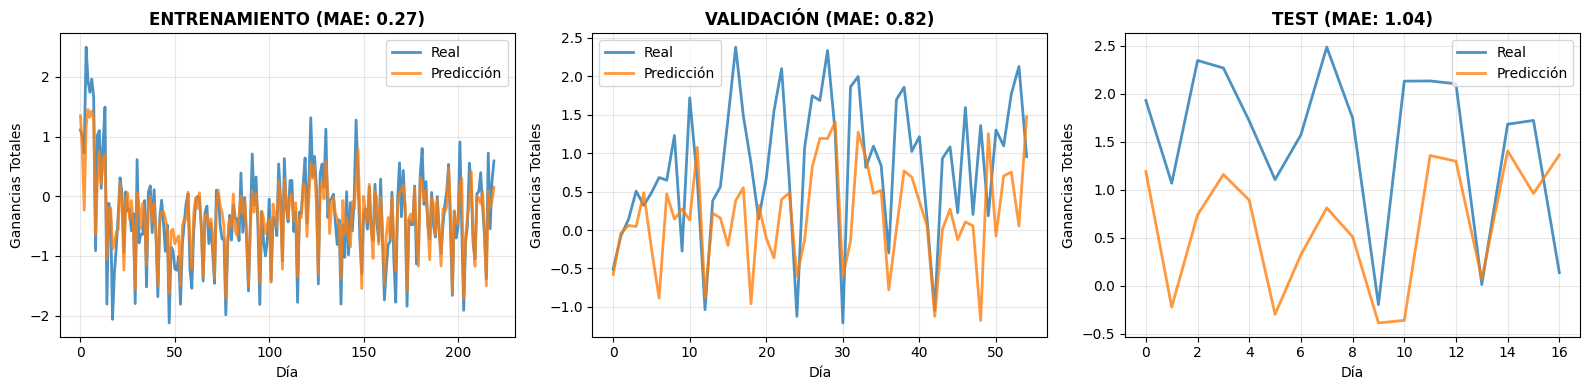

In [72]:
mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100
mape_validation = mean_absolute_percentage_error(y_validation, y_validation_pred) * 100
mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(y_train, label='Real', linewidth=2, alpha=0.8)
axes[0].plot(y_train_pred, label='Predicción', linewidth=2, alpha=0.8)
axes[0].set_title(f'ENTRENAMIENTO (MAE: {mae_train:.2f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Ganancias Totales')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_validation, label='Real', linewidth=2, alpha=0.8)
axes[1].plot(y_validation_pred, label='Predicción', linewidth=2, alpha=0.8)
axes[1].set_title(f'VALIDACIÓN (MAE: {mae_validation:.2f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Ganancias Totales')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(y_test, label='Real', linewidth=2, alpha=0.8)
axes[2].plot(y_test_pred, label='Predicción', linewidth=2, alpha=0.8)
axes[2].set_title(f'TEST (MAE: {mae_test:.2f})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Día')
axes[2].set_ylabel('Ganancias Totales')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()